In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.ticker import FuncFormatter

# ── Data ──────────────────────────────────────────────────────────────────────
# One-at-a-time sampling
rmse_oat = pd.read_csv('rmse_oaat.csv',           index_col='epoch')
comm_oat = pd.read_csv('commute_oaat.csv',           index_col='epoch')

# Random sampling
rmse_rs  = pd.read_csv('val_rmse_per_epoch (rs).csv',   index_col='Epoch')
comm_rs  = pd.read_csv('cumulative_comm_cost (rs).csv', index_col='Epoch')


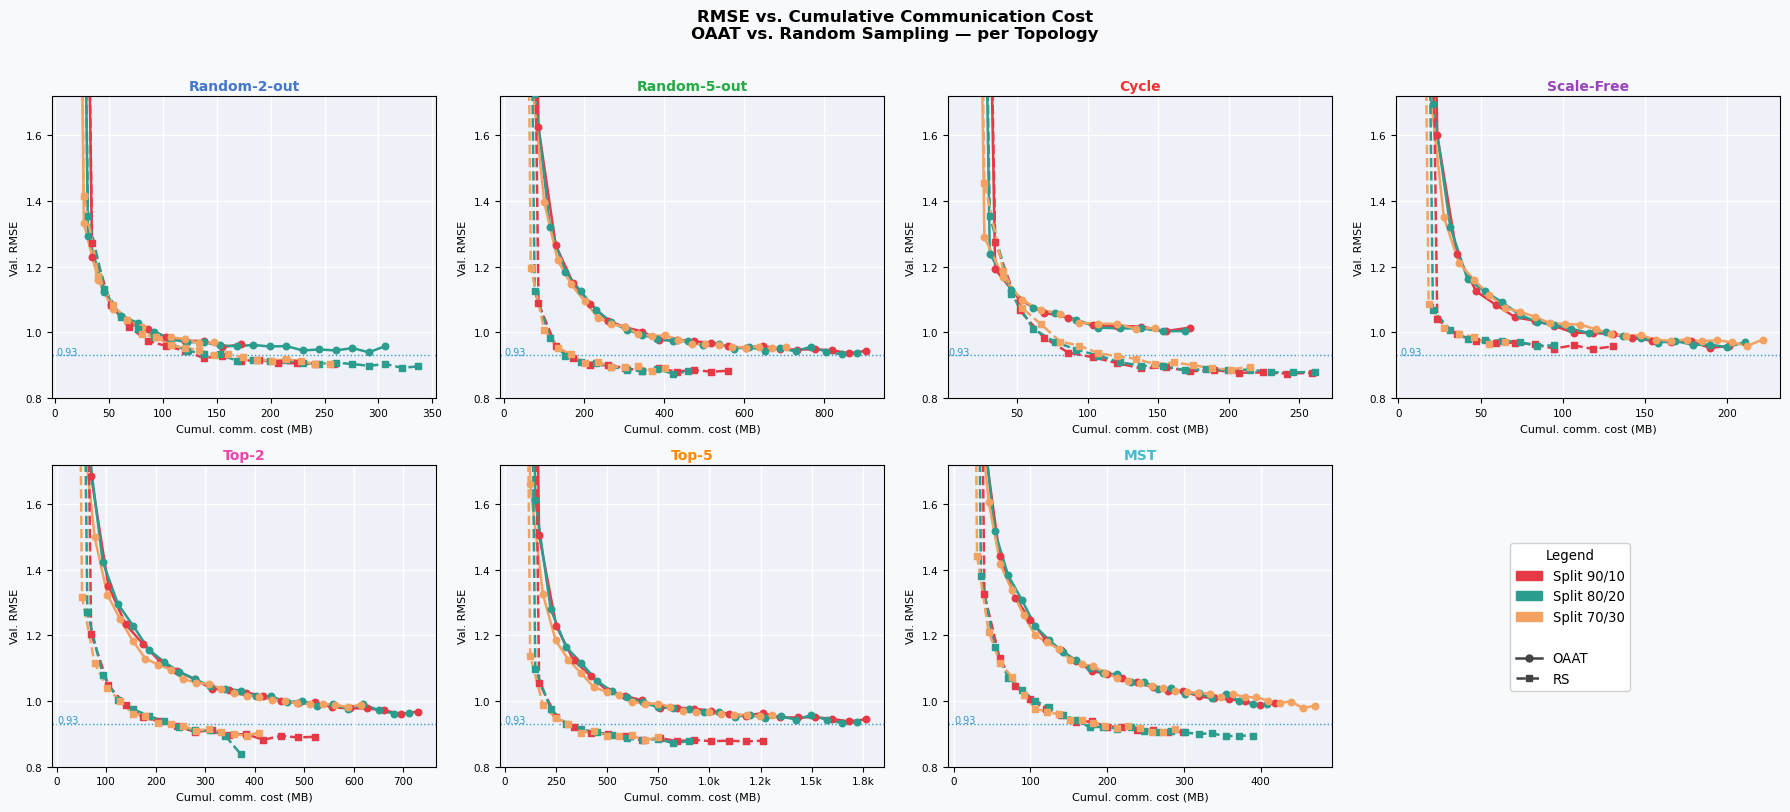

In [2]:
# ── Style ─────────────────────────────────────────────────────────────────────
topologies = {
    'Random2out': ('Random-2-out', '#4477CC'),
    'Random5out': ('Random-5-out', '#22AA44'),
    'Cycle':      ('Cycle',        '#EE3333'),
    'ScaleFree':  ('Scale-Free',   '#9944BB'),
    'Top2':       ('Top-2',        '#EE44AA'),
    'Top5':       ('Top-5',        '#FF8800'),
    'MST':        ('MST',          '#44BBCC'),
}
 
# Each split ratio gets a distinct color
split_color = {'90/10': '#E63946', '80/20': '#2A9D8F', '70/30': '#F4A261'}
splits = ['90/10', '80/20', '70/30']
 
schemes = [
    ('OAAT', rmse_oat, comm_oat, '-',  'o'),
    ('RS',   rmse_rs,  comm_rs,  '--', 's'),
]
 
def xfmt(v, _):
    return f'{v/1000:.1f}k' if v >= 1000 else f'{int(v)}'
 
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
fig.patch.set_facecolor('#F8F9FB')
 
for idx, (topo, (topo_label, topo_color)) in enumerate(topologies.items()):
    ax = axes[idx]
    ax.set_facecolor('#EEF1F7')
    ax.grid(True, color='white', linewidth=1.0, zorder=0)
 
    for scheme_name, rmse_df, comm_df, ls, marker in schemes:
        for split in splits:
            col = f'{topo}_{split}'
            if col not in rmse_df.columns or col not in comm_df.columns:
                continue
            x = comm_df[col].dropna()
            y = rmse_df[col].dropna()
            common_idx = x.index.intersection(y.index)
            if len(common_idx) < 2:
                continue
            xv, yv = x[common_idx].values, y[common_idx].values
 
            ax.plot(xv, yv, color=split_color[split], linewidth=1.8,
                    linestyle=ls, zorder=2)
            ax.scatter(xv, yv, color=split_color[split], s=22,
                       marker=marker, zorder=3)
 
    # Reference line at RMSE = 0.93
    ax.axhline(0.93, color='#3399CC', linewidth=1.0, linestyle=':', zorder=1)
    ax.text(1, 0.932, '0.93', color='#3399CC', fontsize=7)
 
    ax.set_title(topo_label, fontsize=10, fontweight='bold',
                 color=topo_color, pad=4)
    ax.set_xlabel('Cumul. comm. cost (MB)', fontsize=8)
    ax.set_ylabel('Val. RMSE', fontsize=8)
    ax.tick_params(labelsize=7.5)
    ax.set_ylim(0.8, 1.72)
    ax.xaxis.set_major_formatter(FuncFormatter(xfmt))
 
# 8th panel → legend
axes[7].set_visible(False)
 
# Split ratio colour patches
split_patches = [
    mpatches.Patch(color=split_color[s], label=f'Split {s}')
    for s in splits
]
# Sampling scheme line/marker handles
scheme_handles = [
    mlines.Line2D([], [], color='#444444', linewidth=1.8, linestyle='-',
                  marker='o', markersize=5, label='OAAT'),
    mlines.Line2D([], [], color='#444444', linewidth=1.8, linestyle='--',
                  marker='s', markersize=4, label='RS'),
]
 
fig.legend(
    handles=split_patches + [mpatches.Patch(visible=False)] + scheme_handles,
    loc='center',
    bbox_to_anchor=(0.875, 0.25),
    fontsize=9.5, frameon=True, framealpha=0.9, edgecolor='#cccccc',
    title='Legend', title_fontsize=9.5
)
 
fig.suptitle(
    'RMSE vs. Cumulative Communication Cost\nOAAT vs. Random Sampling — per Topology',
    fontsize=12, fontweight='bold', y=1.01
)
 
plt.tight_layout()
plt.savefig('rmse_commcost_per_topo.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()